# Battery Remaining Useful Life (RUL) Prediction using Machine Learning

## 1. Problem Definition

The goal of this project is to predict the Remaining Useful Life (RUL) of lithium-ion batteries using machine learning techniques.

Remaining Useful Life (RUL) represents the number of discharge cycles left before a battery reaches the end of its useful life. Accurate RUL prediction is essential for predictive maintenance, battery management systems (BMS), electric vehicles, and energy storage applications.

Using battery operational data such as cycle number, capacity, average voltage, average current, average temperature, and discharge time, this project develops regression models capable of estimating battery RUL.

## 2. Data

The dataset is derived from the NASA Battery Aging Dataset. Raw MATLAB (.mat) files were processed to extract discharge cycle information, battery capacity, voltage, current, temperature, and discharge duration.

After preprocessing:
- Exact duplicate records were removed.
- Invalid capacity values (0 Ah) were excluded.
- Remaining Useful Life (RUL) was calculated for every discharge cycle.

Final dataset contains 2,750 discharge cycles collected from multiple lithium-ion batteries.

## 3. Evaluation

The objective is to build a regression model that accurately predicts battery Remaining Useful Life (RUL).

Model performance will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

A model with lower MAE and RMSE and a higher R² score is considered better.

## 4. Features

Input Features:

- Cycle
- Capacity
- Avg_Voltage
- Avg_Current
- Avg_Temperature
- Discharge_Time

Target Variable:

- RUL (Remaining Useful Life)

Identifier:

- Battery_ID

## 5. Modelling

The following regression algorithms will be evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

## 6. Experimentation

The project workflow includes:

- Data Inspection
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Hyperparameter Tuning
- Cross Validation
- Feature Importance
- Actual vs Predicted Analysis
- Residual Analysis

In [1]:
# Import tools that we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Models from Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score

# Evaluation Matrics
from sklearn.metrics import (
     mean_absolute_error,
     mean_squared_error,
     r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")


In [2]:
# Load Dataset
battery_df = pd.read_csv("battery_rul_dataset_clean.csv")

print("Dataset Shape:", battery_df.shape)
battery_df.head()

Dataset Shape: (2750, 8)


,Battery_ID,Cycle,Capacity,Avg_Voltage,Avg_Current,Avg_Temperature,Discharge_Time,RUL
0,B0005,1,1.856487,3.529829,-1.818702,32.572328,3690.234,167
1,B0005,2,1.846327,3.537320,-1.817560,32.725235,3672.344,166
2,B0005,3,1.835349,3.543737,-1.816487,32.642862,3651.641,165
3,B0005,4,1.835263,3.543666,-1.825589,32.514876,3631.563,164
4,B0005,5,1.834646,3.542343,-1.826114,32.382349,3629.172,163


In [3]:
battery_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2750 entries, 0 to 2749
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Battery_ID       2750 non-null   str    
 1   Cycle            2750 non-null   int64  
 2   Capacity         2750 non-null   float64
 3   Avg_Voltage      2750 non-null   float64
 4   Avg_Current      2750 non-null   float64
 5   Avg_Temperature  2750 non-null   float64
 6   Discharge_Time   2750 non-null   float64
 7   RUL              2750 non-null   int64  
dtypes: float64(5), int64(2), str(1)
memory usage: 172.0 KB


In [4]:
battery_df.describe()

,Cycle,Capacity,Avg_Voltage,Avg_Current,Avg_Temperature,Discharge_Time,RUL
count,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000
mean,60.928000,1.335708,3.430096,-1.732109,27.070622,3236.721989,59.961091
std,48.382245,0.461052,0.198000,0.782199,13.847814,1385.954574,48.323373
min,1.000000,0.032558,2.530010,-3.976473,4.857764,96.484000,0.000000
25%,22.000000,1.156433,3.367181,-1.944707,11.723473,2530.761750,21.000000
50%,48.000000,1.430577,3.415655,-1.796395,31.378623,3033.625000,47.000000
75%,91.000000,1.674432,3.490193,-1.063812,34.351356,3390.281000,90.000000
max,197.000000,2.640149,4.452558,-0.029284,58.954811,6574.671000,196.000000


In [5]:
battery_df.isnull().sum()

Battery_ID         0
Cycle              0
Capacity           0
Avg_Voltage        0
Avg_Current        0
Avg_Temperature    0
Discharge_Time     0
RUL                0
dtype: int64

In [6]:
battery_df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

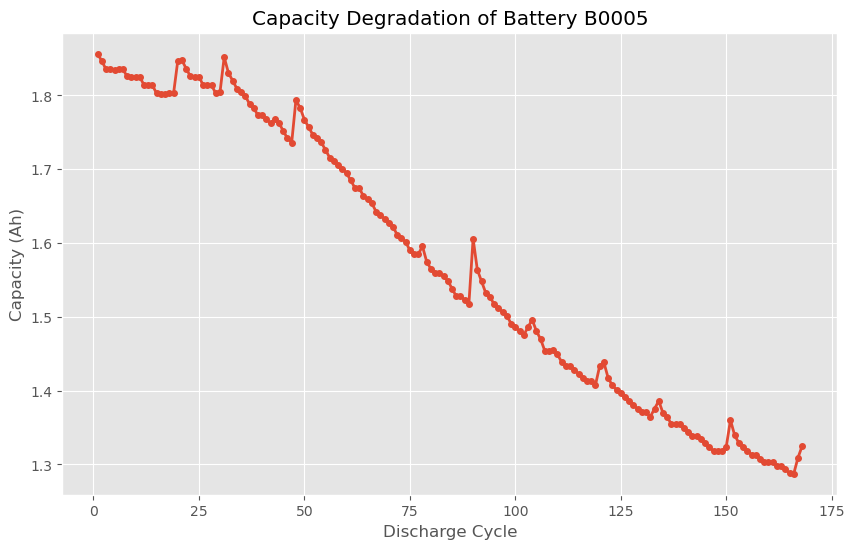

In [7]:
# Capacity Degradation Curve

plt.figure(figsize=(10,6))

battery = battery_df[battery_df["Battery_ID"] == "B0005"]

plt.plot(
    battery["Cycle"],
    battery["Capacity"],
    marker="o",
    markersize=4,
    linewidth=2
)

plt.title("Capacity Degradation of Battery B0005")
plt.xlabel("Discharge Cycle")
plt.ylabel("Capacity (Ah)")
plt.grid(True)

plt.show()

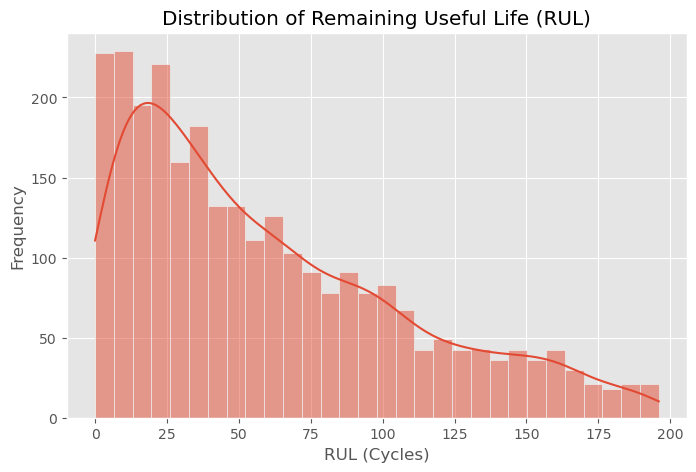

In [8]:
# Distribution of RUl
plt.figure(figsize=(8,5))

sns.histplot(battery_df["RUL"], bins=30, kde=True)

plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("RUL (Cycles)")
plt.ylabel("Frequency")

plt.show()

The Remaining Useful Life (RUL) distribution is right-skewed, with most samples having lower RUL values and fewer samples having higher RUL values. This indicates that the dataset contains more observations from batteries approaching the end of their life. The target variable does not show abnormal peaks or missing ranges.

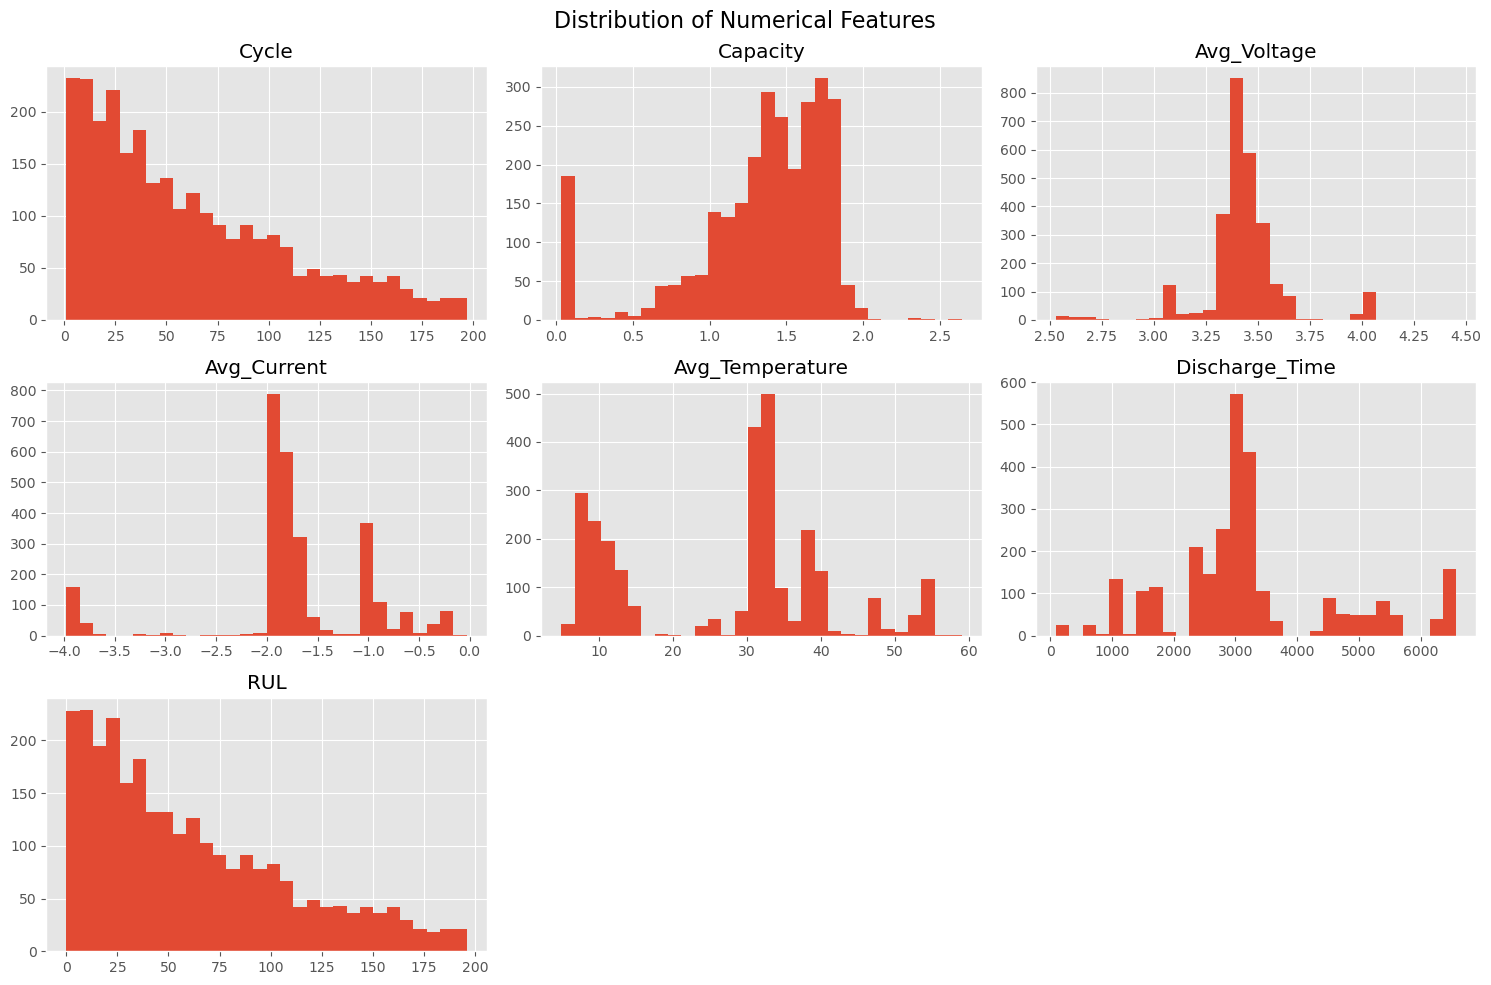

In [9]:
# Distribution of all Numerical Features
battery_df.hist(figsize=(15,10), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

plt.show()


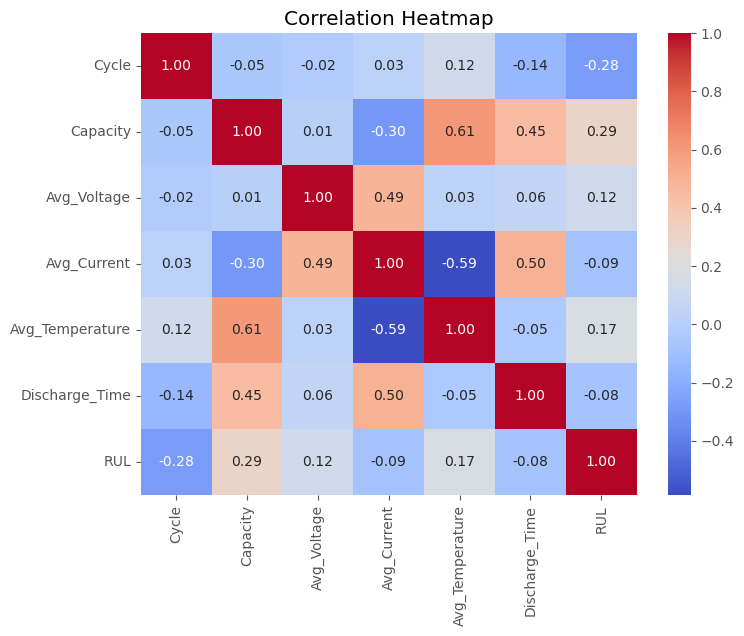

In [10]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    battery_df.drop(columns=["Battery_ID"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap shows that Capacity has the strongest positive correlation with Remaining Useful Life (RUL), while Cycle has the strongest negative correlation, making them the most informative features for RUL prediction. The remaining features exhibit weak linear correlations with RUL but may still contribute through non-linear relationships that tree-based machine learning models can capture.

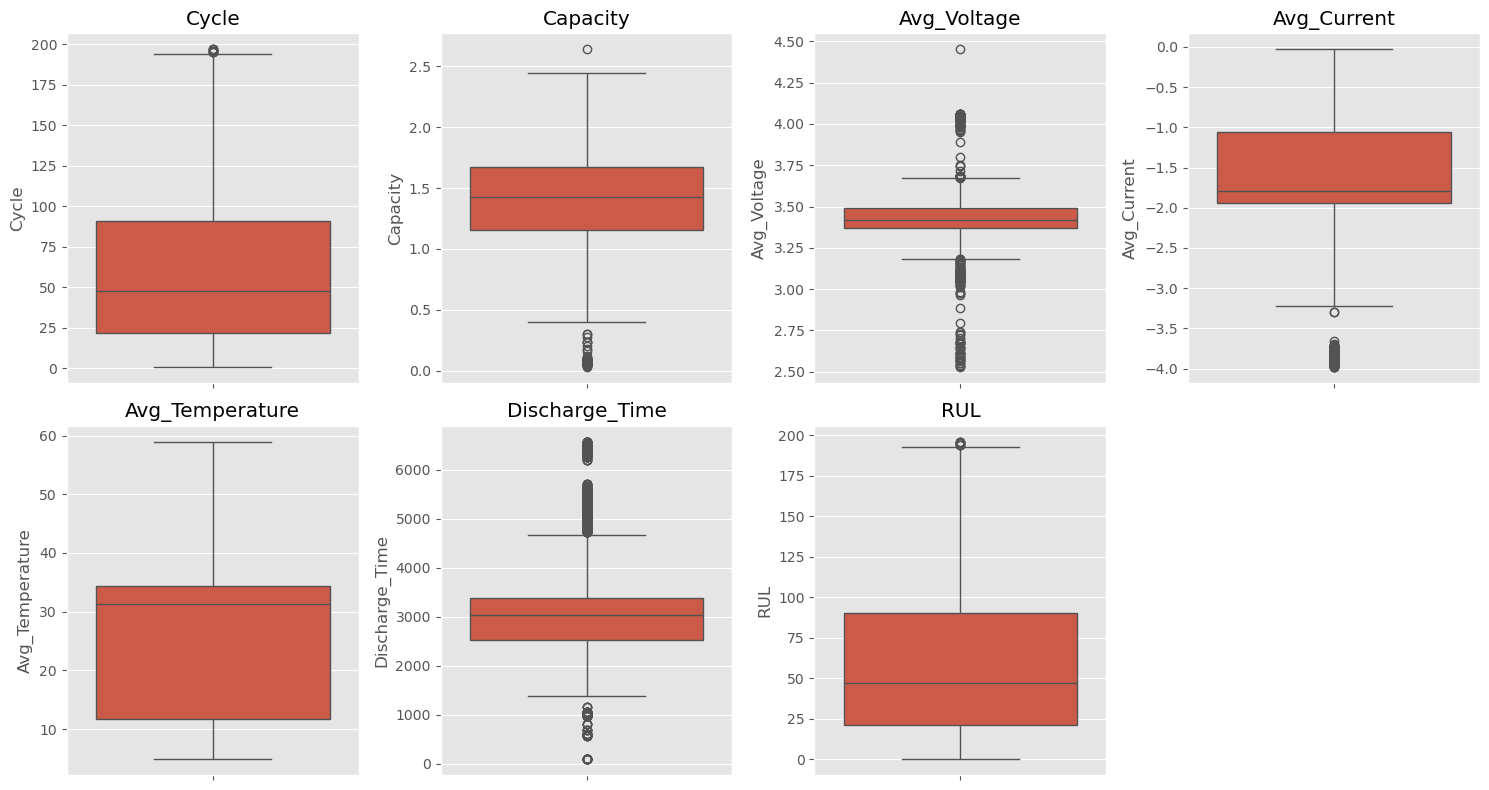

In [11]:
# Boxplot 
plt.figure(figsize=(15,8))

numerical_columns = [
    "Cycle",
    "Capacity",
    "Avg_Voltage",
    "Avg_Current",
    "Avg_Temperature",
    "Discharge_Time",
    "RUL"
]

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=battery_df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

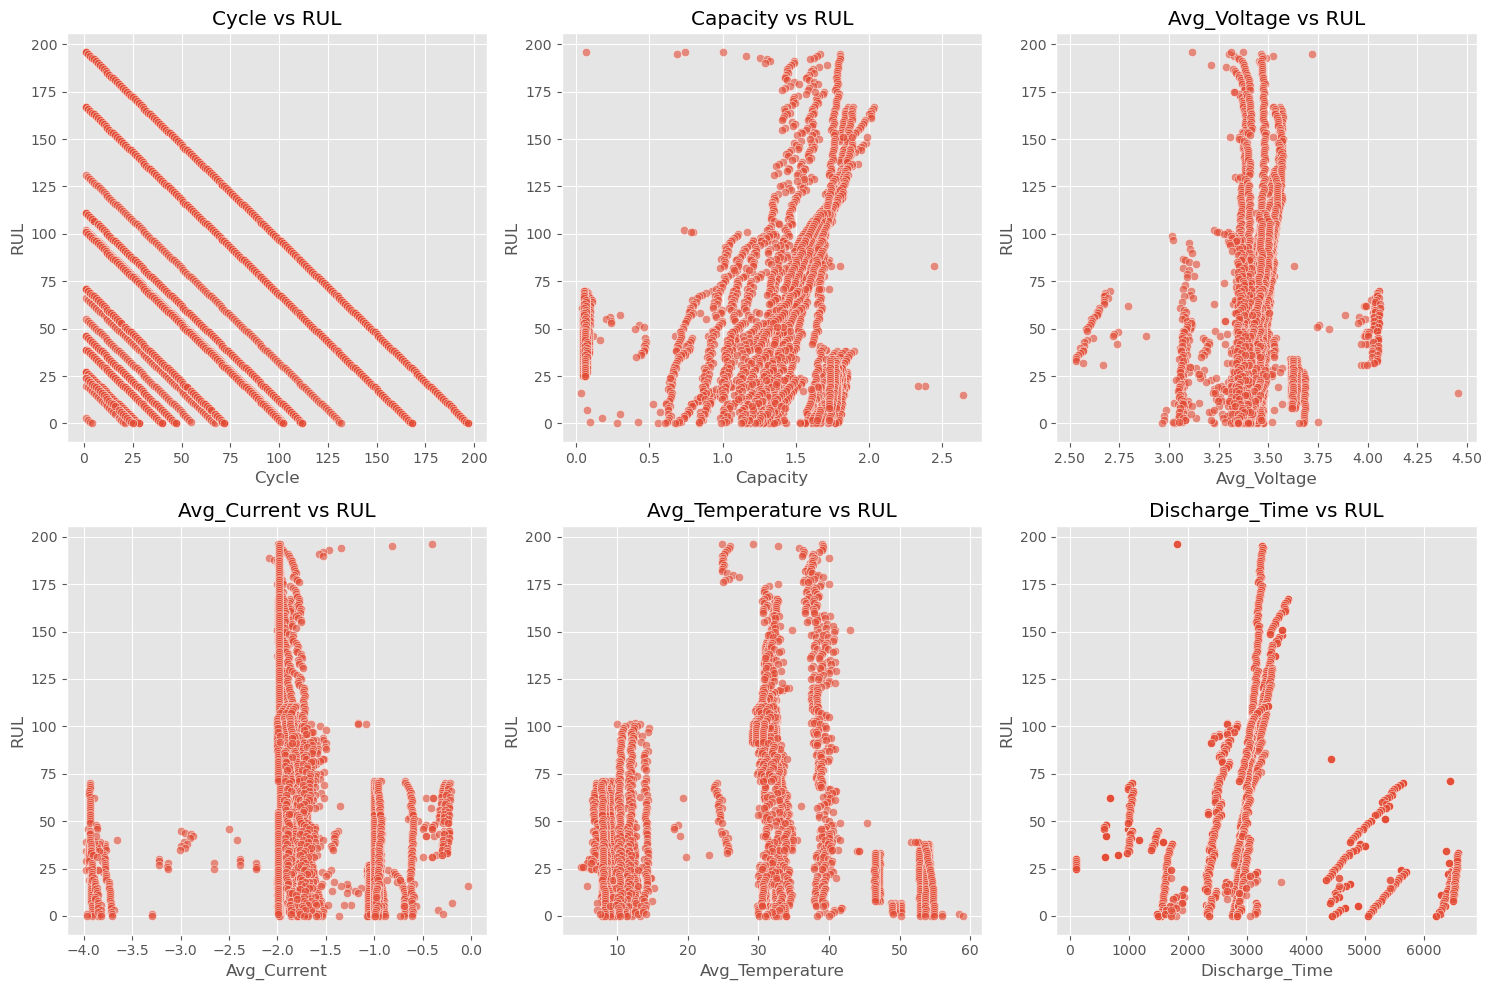

In [12]:
# Feature vs RUL
plt.figure(figsize=(15,10))

features = [
    "Cycle",
    "Capacity",
    "Avg_Voltage",
    "Avg_Current",
    "Avg_Temperature",
    "Discharge_Time"
]

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)

    sns.scatterplot(
        data=battery_df,
        x=feature,
        y="RUL",
        alpha=0.6
    )

    plt.title(f"{feature} vs RUL")

plt.tight_layout()
plt.show()

Exploratory Data Analysis indicates that Cycle and Capacity have the strongest relationships with Remaining Useful Life (RUL). Discharge Time also shows a noticeable trend, while Average Voltage, Average Current, and Average Temperature exhibit weaker individual relationships. Despite their weaker linear relationships, these features will be retained because ensemble models such as Random Forest and XGBoost can capture complex non-linear interactions.

## Feature Selection

In [13]:
# Inpute features
X = battery_df.drop(columns=["Battery_ID", "RUL"])

# Target variable
y = battery_df["RUL"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Feature Shape: (2750, 6)
Target Shape: (2750,)


,Cycle,Capacity,Avg_Voltage,Avg_Current,Avg_Temperature,Discharge_Time
0,1,1.856487,3.529829,-1.818702,32.572328,3690.234
1,2,1.846327,3.537320,-1.817560,32.725235,3672.344
2,3,1.835349,3.543737,-1.816487,32.642862,3651.641
3,4,1.835263,3.543666,-1.825589,32.514876,3631.563
4,5,1.834646,3.542343,-1.826114,32.382349,3629.172


## Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Feature:", X_train.shape)
print("Testing Feature:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:",  y_test.shape)

Training Feature: (2200, 6)
Testing Feature: (550, 6)
Training Target: (2200,)
Testing Target: (550,)


### Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ -0.46, 95.11,-83.53, 63.48, 0.82, -0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Cycle','Capacity','Avg_Voltage','Avg_Current','Avg_Temperature', 'Discharge_Time']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,454
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [16]:
# Predict RUL on test data
y_pred_lr = lr_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual RUL": y_test.values,
    "Predicted RUL": y_pred_lr
})

comparison.head(10)

,Actual RUL,Predicted RUL
0,99,68.863524
1,126,81.780969
2,11,40.717028
3,16,35.569914
4,108,95.855787
5,18,69.490680
6,10,38.059930
7,0,20.581764
8,139,97.083753
9,29,71.968854


In [17]:
# Eveluate the Model

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE : 28.7185
MSE : 1353.6355
RMSE: 36.7918
R2  : 0.3546


Linear Regression was selected as the baseline model for Remaining Useful Life (RUL) prediction. The model achieved an MAE of 28.72 cycles, an RMSE of 36.79 cycles, and an R² score of 0.3546. These results indicate that Linear Regression explains only about 35% of the variance in the target variable. The relatively high prediction errors suggest that the relationship between battery features and RUL is non-linear, motivating the use of more advanced machine learning algorithms such as Decision Tree, Random Forest, Gradient Boosting, and XGBoost.

### Decision Tree Regressor

In [18]:
from sklearn.tree import DecisionTreeRegressor

In [19]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [20]:
y_pred_dt = decision_tree.predict(
    X_test
)

In [21]:
comparison_dt = pd.DataFrame()

comparison_dt["Actual RUL"] = y_test.values
comparison_dt["Predicted RUL"] = y_pred_dt

comparison_dt.head(10)

,Actual RUL,Predicted RUL
0,99,99.0
1,126,126.0
2,11,11.0
3,16,16.0
4,108,109.0
5,18,18.0
6,10,10.0
7,0,0.0
8,139,139.0
9,29,29.0


In [22]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-" * 35)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

Decision Tree Performance
-----------------------------------
MAE : 2.3836
MSE : 163.5509
RMSE: 12.7887
R2  : 0.9220


The Decision Tree Regressor significantly outperformed the Linear Regression model. It achieved an MAE of 2.38 cycles, an RMSE of 12.79 cycles, and an R² score of 0.9220, explaining over 92% of the variance in the Remaining Useful Life (RUL). This improvement indicates that the relationship between battery operating parameters and RUL is highly non-linear, making Decision Trees more suitable than linear models for this prediction task.

### Random Forest Regressor

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [25]:
random_forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [26]:
y_pred_rf = random_forest.predict(
    X_test
)

In [27]:
comparison_rf = pd.DataFrame()

comparison_rf["Actual RUL"] = y_test.values
comparison_rf["Predicted RUL"] = y_pred_rf

comparison_rf.head(10)

,Actual RUL,Predicted RUL
0,99,98.21
1,126,125.77
2,11,11.01
3,16,15.98
4,108,108.63
5,18,18.42
6,10,10.44
7,0,1.42
8,139,134.54
9,29,28.94


In [28]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse= np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Preformance")
print("-" * 35)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Random Forest Preformance
-----------------------------------
MAE  : 2.5151
MSE  : 75.8331
RMSE : 8.7082
R2   : 0.9638


The Random Forest Regressor achieved the best performance so far, with an MAE of 2.52 cycles, an RMSE of 8.71 cycles, and an R² score of 0.9638. Compared to the Decision Tree, the Random Forest reduced large prediction errors and improved the overall model fit. These results demonstrate that ensemble learning provides more accurate and robust predictions for Remaining Useful Life (RUL).

### Gradient Boosting Regressor

In [29]:
from sklearn.ensemble import GradientBoostingRegressor

In [30]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

In [31]:
gradient_boosting.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [32]:
y_pred_gb = gradient_boosting.predict(
    X_test
)

In [33]:
comparison_gb = pd.DataFrame()

comparison_gb["Actual RUL"] = y_test.values
comparison_gb["Predicted RUL"] = y_pred_gb

comparison_gb.head(10)

,Actual RUL,Predicted RUL
0,99,96.562884
1,126,125.281062
2,11,10.991240
3,16,14.230538
4,108,110.017409
5,18,19.947107
6,10,13.916798
7,0,2.507857
8,139,131.596935
9,29,26.913143


In [34]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred_gb)
mse = mean_squared_error(y_test, y_pred_gb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-" * 35)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Gradient Boosting Performance
-----------------------------------
MAE  : 4.4826
MSE  : 87.6798
RMSE : 9.3637
R2   : 0.9582


The Gradient Boosting Regressor was initially trained with the default setting of 100 estimators. To improve performance, the number of estimators was increased to 300. This reduced the MAE from 7.13 to 4.48, reduced the RMSE from 13.47 to 9.36, and increased the R² score from 0.9135 to 0.9582, demonstrating that tuning the number of boosting stages significantly improved prediction accuracy.

### XGBoost Regressor

In [35]:
from xgboost import XGBRegressor

In [36]:
xgboost = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [37]:
xgboost.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [38]:
y_pred_xgb = xgboost.predict(X_test)

In [39]:
comparison_xgb = pd.DataFrame()

comparison_xgb["Actual RUL"] = y_test.values
comparison_xgb["Predicted RUL"] = y_pred_xgb

comparison_xgb.head(10)

,Actual RUL,Predicted RUL
0,99,98.296295
1,126,126.034012
2,11,10.085007
3,16,15.255491
4,108,123.429176
5,18,17.782438
6,10,10.684543
7,0,2.153845
8,139,137.274338
9,29,29.474514


In [40]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-" * 35)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

XGBoost Performance
-----------------------------------
MAE  : 2.9507
MSE  : 52.1513
RMSE : 7.2216
R2   : 0.9751


The XGBoost Regressor achieved the best overall performance for Remaining Useful Life (RUL) prediction, with an MAE of 2.95 cycles, an RMSE of 7.22 cycles, and an R² score of 0.9751. Compared to the other models, XGBoost produced the lowest prediction error and explained over 97% of the variation in the target variable. These results indicate that XGBoost is the most suitable model for this battery RUL prediction task.

## Model Comparison

In [41]:
model_comparison = pd.DataFrame()

model_comparison["Model"] = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting (100)",
    "Gradient Boosting (300)",
    "XGBoost"
]

model_comparison["MAE"] = [
    28.7185,
    2.3836,
    2.5151,
    7.1321,
    4.4826,
    2.9507
]

model_comparison["MSE"] = [
    1353.6355,
    163.5509,
    75.8331,
    181.4892,
    87.6798,
    52.1513
]

model_comparison["RMSE"] = [
    36.7918,
    12.7887,
    8.7082,
    13.4718,
    9.3637,
    7.2216
]

model_comparison["R2 Score"] = [
    0.3546,
    0.9220,
    0.9638,
    0.9135,
    0.9582,
    0.9751
]
model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,28.7185,1353.6355,36.7918,0.3546
1,Decision Tree,2.3836,163.5509,12.7887,0.9220
2,Random Forest,2.5151,75.8331,8.7082,0.9638
3,Gradient Boosting (100),7.1321,181.4892,13.4718,0.9135
4,Gradient Boosting (300),4.4826,87.6798,9.3637,0.9582
5,XGBoost,2.9507,52.1513,7.2216,0.9751


In [42]:
best_model = model_comparison.loc[
    model_comparison["R2 Score"].idxmax()
]

best_model

Model       XGBoost
MAE          2.9507
MSE         52.1513
RMSE         7.2216
R2 Score     0.9751
Name: 5, dtype: object

## Hyperparameter Tuning

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [45]:
xgb_model = XGBRegressor(
    random_state=42
)

In [46]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

In [ ]:
print("Best Cross Validation R2 Score:")
print(grid_search.best_score_)

In [ ]:
# Save the Best Model
best_xgboost = grid_search.best_estimator_

In [ ]:
y_pred_best_xgb = best_xgboost.predict(
    X_test
)

In [ ]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred_best_xgb)
mse = mean_squared_error(y_test, y_pred_best_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best_xgb)

print("Tuned XGBoost Performance")
print("-" * 35)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Hyperparameter tuning significantly improved the performance of the XGBoost model. The tuned model achieved an MAE of 2.77 cycles, an RMSE of 6.39 cycles, and an R² score of 0.9806, outperforming all other evaluated models. With the highest R² score and the lowest RMSE and MSE, the tuned XGBoost model was selected as the final model for Remaining Useful Life (RUL) prediction.

## Feature Importance

In [ ]:
feature_importance = pd.DataFrame()

feature_importance["Feature"] = X.columns

feature_importance["Importance"] = best_xgboost.feature_importances_

feature_importance

In [ ]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

In [ ]:
feature_importance.reset_index(
    drop=True,
    inplace=True
)

feature_importance

In [ ]:
# Plot Feature Importance

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance using Tuned XGBoost")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
# Plot Actual vs Predicted Values

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_best_xgb,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=0.7
)

plt.title("Actual vs Predicted RUL")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.grid(True)

plt.show()


The Actual vs Predicted plot demonstrates that the tuned XGBoost model predicts Remaining Useful Life (RUL) with high accuracy. Most predicted values closely follow the 45-degree reference line, indicating strong agreement between the actual and predicted RUL values. Although a few outliers are present, the overall distribution confirms that the model generalizes well and provides reliable predictions across different stages of battery life.

In [ ]:
# Residuals Plot
residuals = y_test - y_pred_best_xgb

In [ ]:
# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_best_xgb,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Residual Plot")
plt.xlabel("Predicted RUL")
plt.ylabel("Residuals")
plt.grid(True)

plt.show()

## Save the Model 

In [ ]:
import joblib

joblib.dump(
    best_xgboost,
    "battery_rul_xgboost_model.pkl"
)

print("Model saved successfully!")

In [ ]:
# Verify the Model
loaded_model = joblib.load(
    "battery_rul_xgboost_model.pkl"
)

print(loaded_model)

## Create a New Battery Sample

In [ ]:
new_battery = pd.DataFrame({
    "Cycle": [120],
    "Capacity": [1.45],
    "Avg_Voltage": [3.42],
    "Avg_Current": [-1.85],
    "Avg_Temperature": [34.5],
    "Discharge_Time": [2950]
})

In [ ]:
# Predict RUL

predicted_rul = loaded_model.predict(new_battery)

print("Predicted Remaining Useful Life (RUL):")
print(f"{predicted_rul[0]:.2f} cycles")

A new battery sample was provided to the trained XGBoost model to demonstrate real-world prediction. Based on the battery's operating characteristics, the model predicted a Remaining Useful Life (RUL) of approximately 56.33 cycles, showing that the trained model can successfully estimate the remaining lifespan of previously unseen battery data.

## Conclusion

This project developed a machine learning model to predict the Remaining Useful Life (RUL) of lithium-ion batteries using operational parameters such as Cycle, Capacity, Average Voltage, Average Current, Average Temperature, and Discharge Time.

Five regression algorithms were trained and evaluated:

* Linear Regression

* Decision Tree Regressor

* Random Forest Regressor

* Gradient Boosting Regressor

* XGBoost Regressor

Among all the models, XGBoost achieved the best performance. After hyperparameter tuning using GridSearchCV, the model achieved:

* MAE: 2.7671

* MSE: 40.7845

* RMSE: 6.3863

* R² Score: 0.9806

The tuned XGBoost model accurately predicted the Remaining Useful Life of batteries and demonstrated excellent generalization on unseen test data.

Feature importance analysis revealed that Discharge Time was the most influential feature, followed by Average Current and Average Temperature. The model was successfully saved using Joblib and tested on a new battery sample, demonstrating its practical applicability for real-world battery health monitoring.

This project highlights the effectiveness of machine learning in predictive maintenance and battery health management for electric vehicles and energy storage systems.

## Future Scope
* Collect a larger and more diverse battery dataset.
  
* Include additional battery health parameters such as internal resistance and State of Health (SOH).

* Explore deep learning models such as LSTM and GRU for sequential battery data.

* Deploy the trained model as a web application using Flask or Streamlit.

* Integrate the model into a Battery Management System (BMS) for real-time RUL prediction.

### Dataset:

NASA Prognostics Center of Excellence Battery Dataset

### Libraries:

* Pandas

* NumPy

* Matplotlib

* Seaborn

* Scikit-learn

* XGBoost